# Decision Tree: Bank Customer Churn
This notebook trains and evaluates a Decision Tree model for customer churn prediction.

In [14]:
# 1. Load Processed Dataset
import pandas as pd

df = pd.read_csv('../data/processed/churn_processed.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
# 2. Define Features and Target
X = df.drop('Exited', axis=1)
y = df['Exited']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (10000, 13)
Target shape: (10000,)


In [16]:
# 2b. Encode Categorical Features (One-Hot Encoding)
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
df_cat = X.select_dtypes(include=['object'])
categorical_cols = df_cat.columns.tolist()

# Apply one-hot encoding only if categorical columns exist
if categorical_cols:
    encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    X_encoded = encoder.fit_transform(X[categorical_cols])
    encoded_cols = encoder.get_feature_names_out(categorical_cols)
    X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=X.index)
    # Drop original categorical columns and concat encoded
    X = pd.concat([X.drop(columns=categorical_cols), X_encoded_df], axis=1)
    print('Categorical columns encoded:', categorical_cols)
else:
    print('No categorical columns to encode.')

print('Features after encoding:', X.shape)

Categorical columns encoded: ['Surname', 'Geography', 'Gender']
Features after encoding: (10000, 2944)


In [17]:
# 3. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Train shape: (8000, 2944) (8000,)
Test shape: (2000, 2944) (2000,)


In [18]:
# 4. Model Training
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [19]:
# 5. Prediction
y_pred = dt.predict(X_test)

Accuracy: 0.8100
Precision: 0.5318
Recall: 0.5553
F1-score: 0.5433


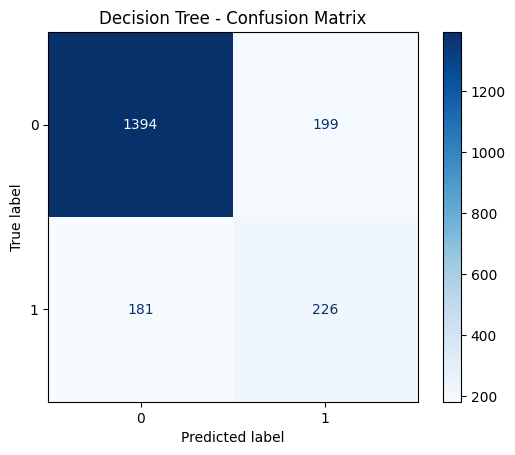

['../outputs/models/decision_tree.joblib']

In [20]:
# 6. Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json
from pathlib import Path

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

# Plot and save confusion matrix
fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
fig.savefig('../outputs/figures/decision_tree_confusion_matrix.png')
plt.show()

# Save metrics
metrics = {
    'model': 'Decision Tree',
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}
Path('../outputs/metrics').mkdir(parents=True, exist_ok=True)
with open('../outputs/metrics/decision_tree_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Save model
import joblib
Path('../outputs/models').mkdir(parents=True, exist_ok=True)
joblib.dump(dt, '../outputs/models/decision_tree.joblib')

# 7. Conclusion

- The Decision Tree model was trained and evaluated on the processed churn dataset.
- All results (metrics, confusion matrix, model) are saved in the outputs folders.
- Key metrics: accuracy, precision, recall, F1-score.
- Use the comparison notebook to see how this model performs against others.